In [26]:
import numpy as np
import matplotlib.pyplot as plt

folderdir = "pots/"
twists = [0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07]
n_tws = len(twists)

pots = [[] for i in range(n_tws)]
steps = [[] for i in range(n_tws)]

# Line to unpack .xvg generated by GROMACS
for i in range(n_tws):
    steps[i], pots[i] = np.loadtxt(folderdir + f"pot-tw{twists[i]}.xvg",comments=["@","#"],unpack=True)


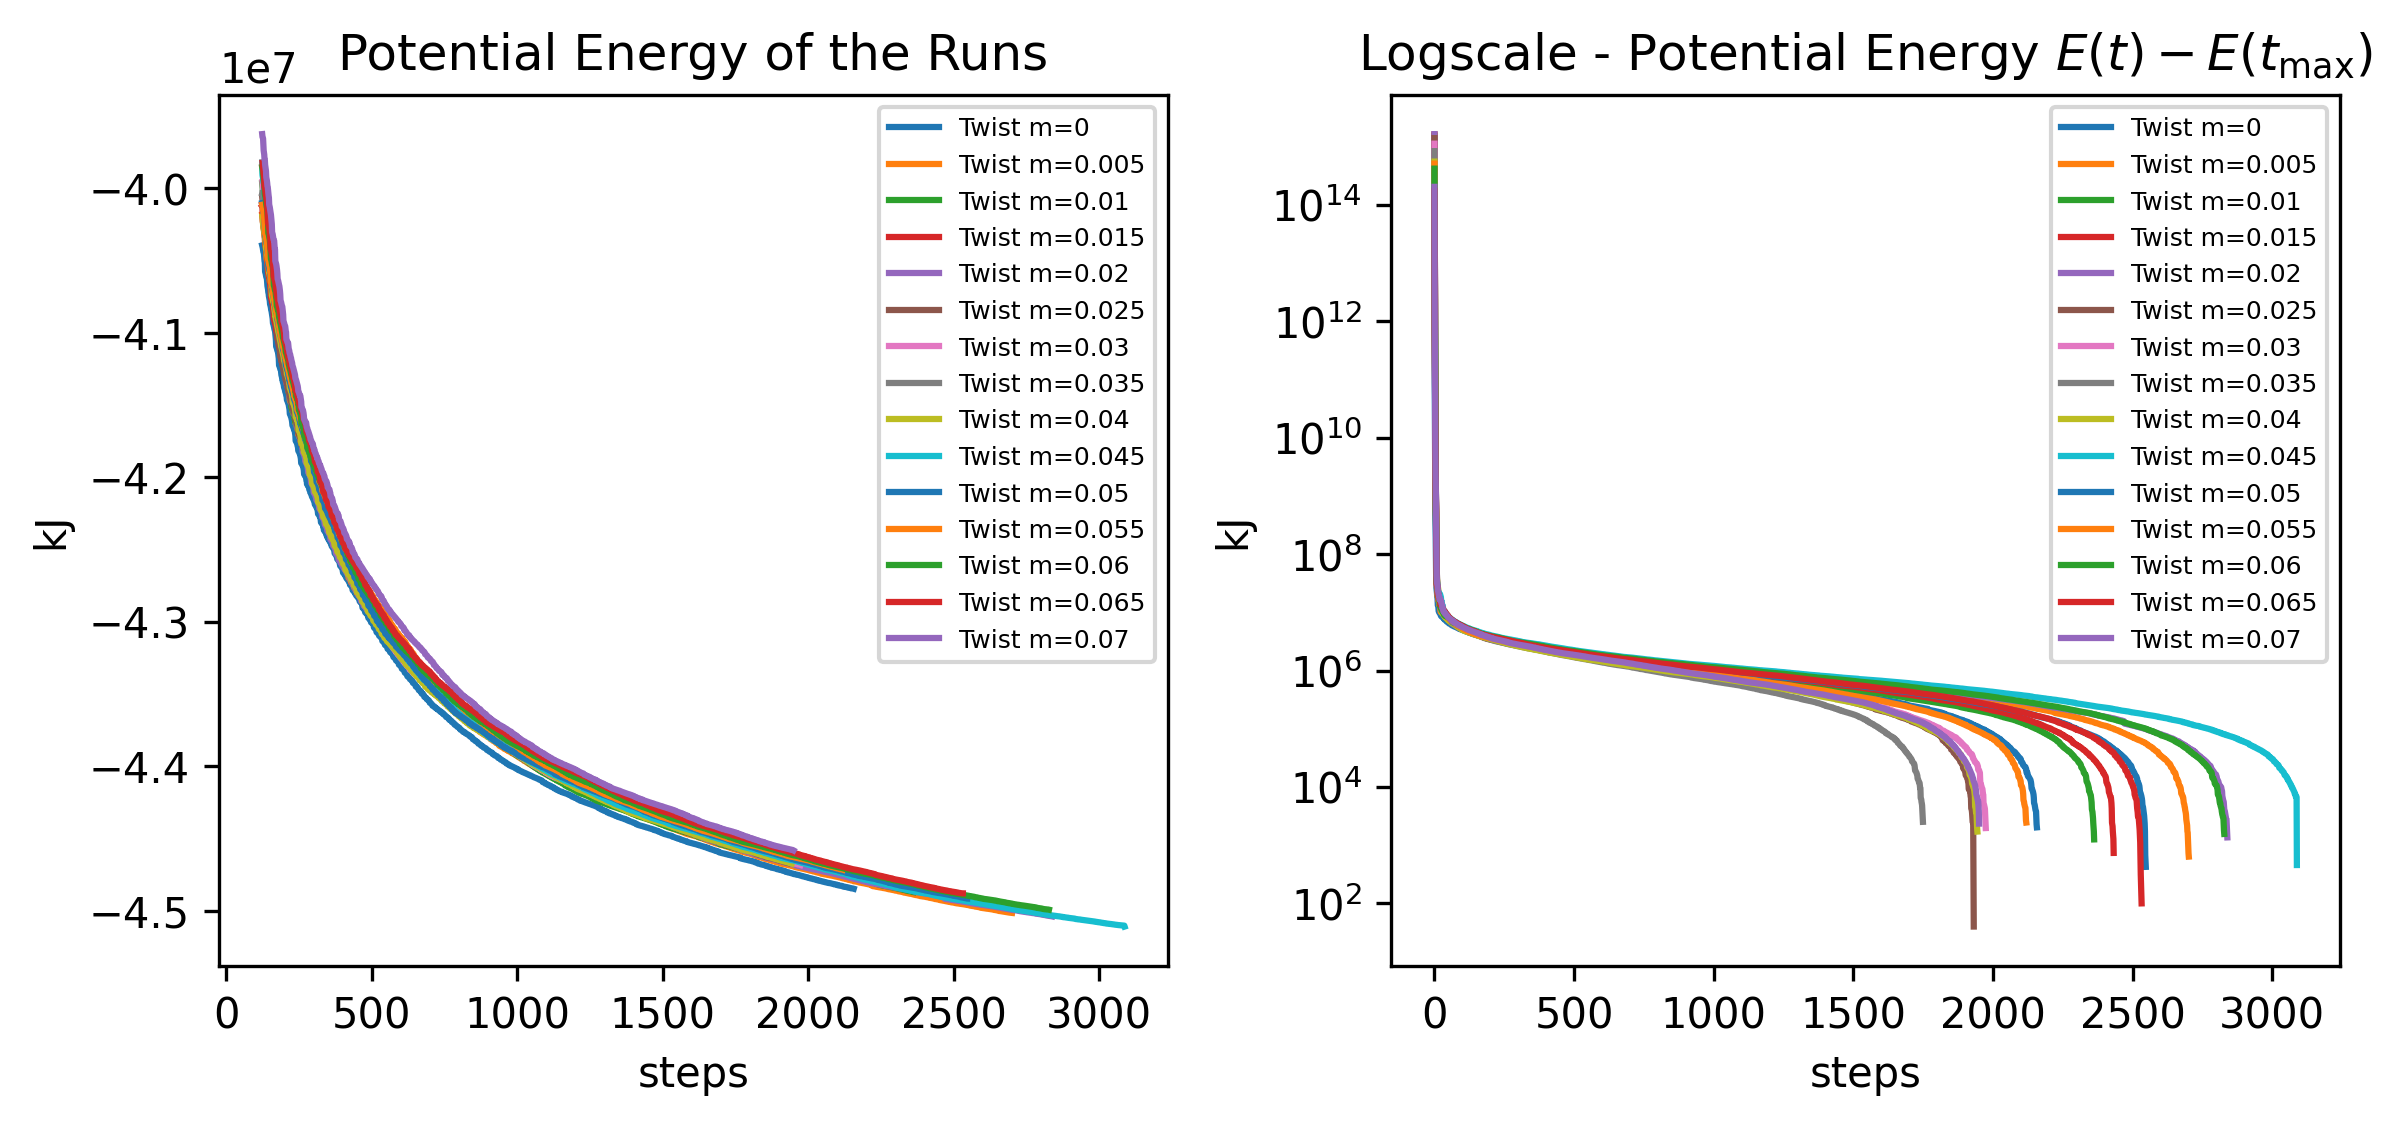

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# --- Normal Plotting ---
initial_step = 100

for i in range(n_tws):
    ene_plot = pots[i][initial_step:-1]
    steps_plot = steps[i][initial_step:-1]
    ax[0].plot(steps_plot, ene_plot, label=f"Twist m={twists[i]}")

ax[0].set_xlabel("steps")
ax[0].set_ylabel("kJ")
ax[0].set_title("Potential Energy of the Runs")
ax[0].legend(fontsize=6)

# --- Log Scale ---
ene_norm = [pots[i] - pots[i][-1] for i in range(n_tws)]

initial_step = 0

for i in range(n_tws):
    ene_plot = ene_norm[i][initial_step:-1]
    steps_plot = steps[i][initial_step:-1]
    ax[1].semilogy(steps_plot, ene_plot, label=f"Twist m={twists[i]}")

ax[1].set_xlabel("steps")
ax[1].set_ylabel("kJ")
ax[1].set_title(r"Logscale - Potential Energy $E(t) - E(t_\text{max})$")
ax[1].legend(fontsize=6)

plt.tight_layout()
plt.show()

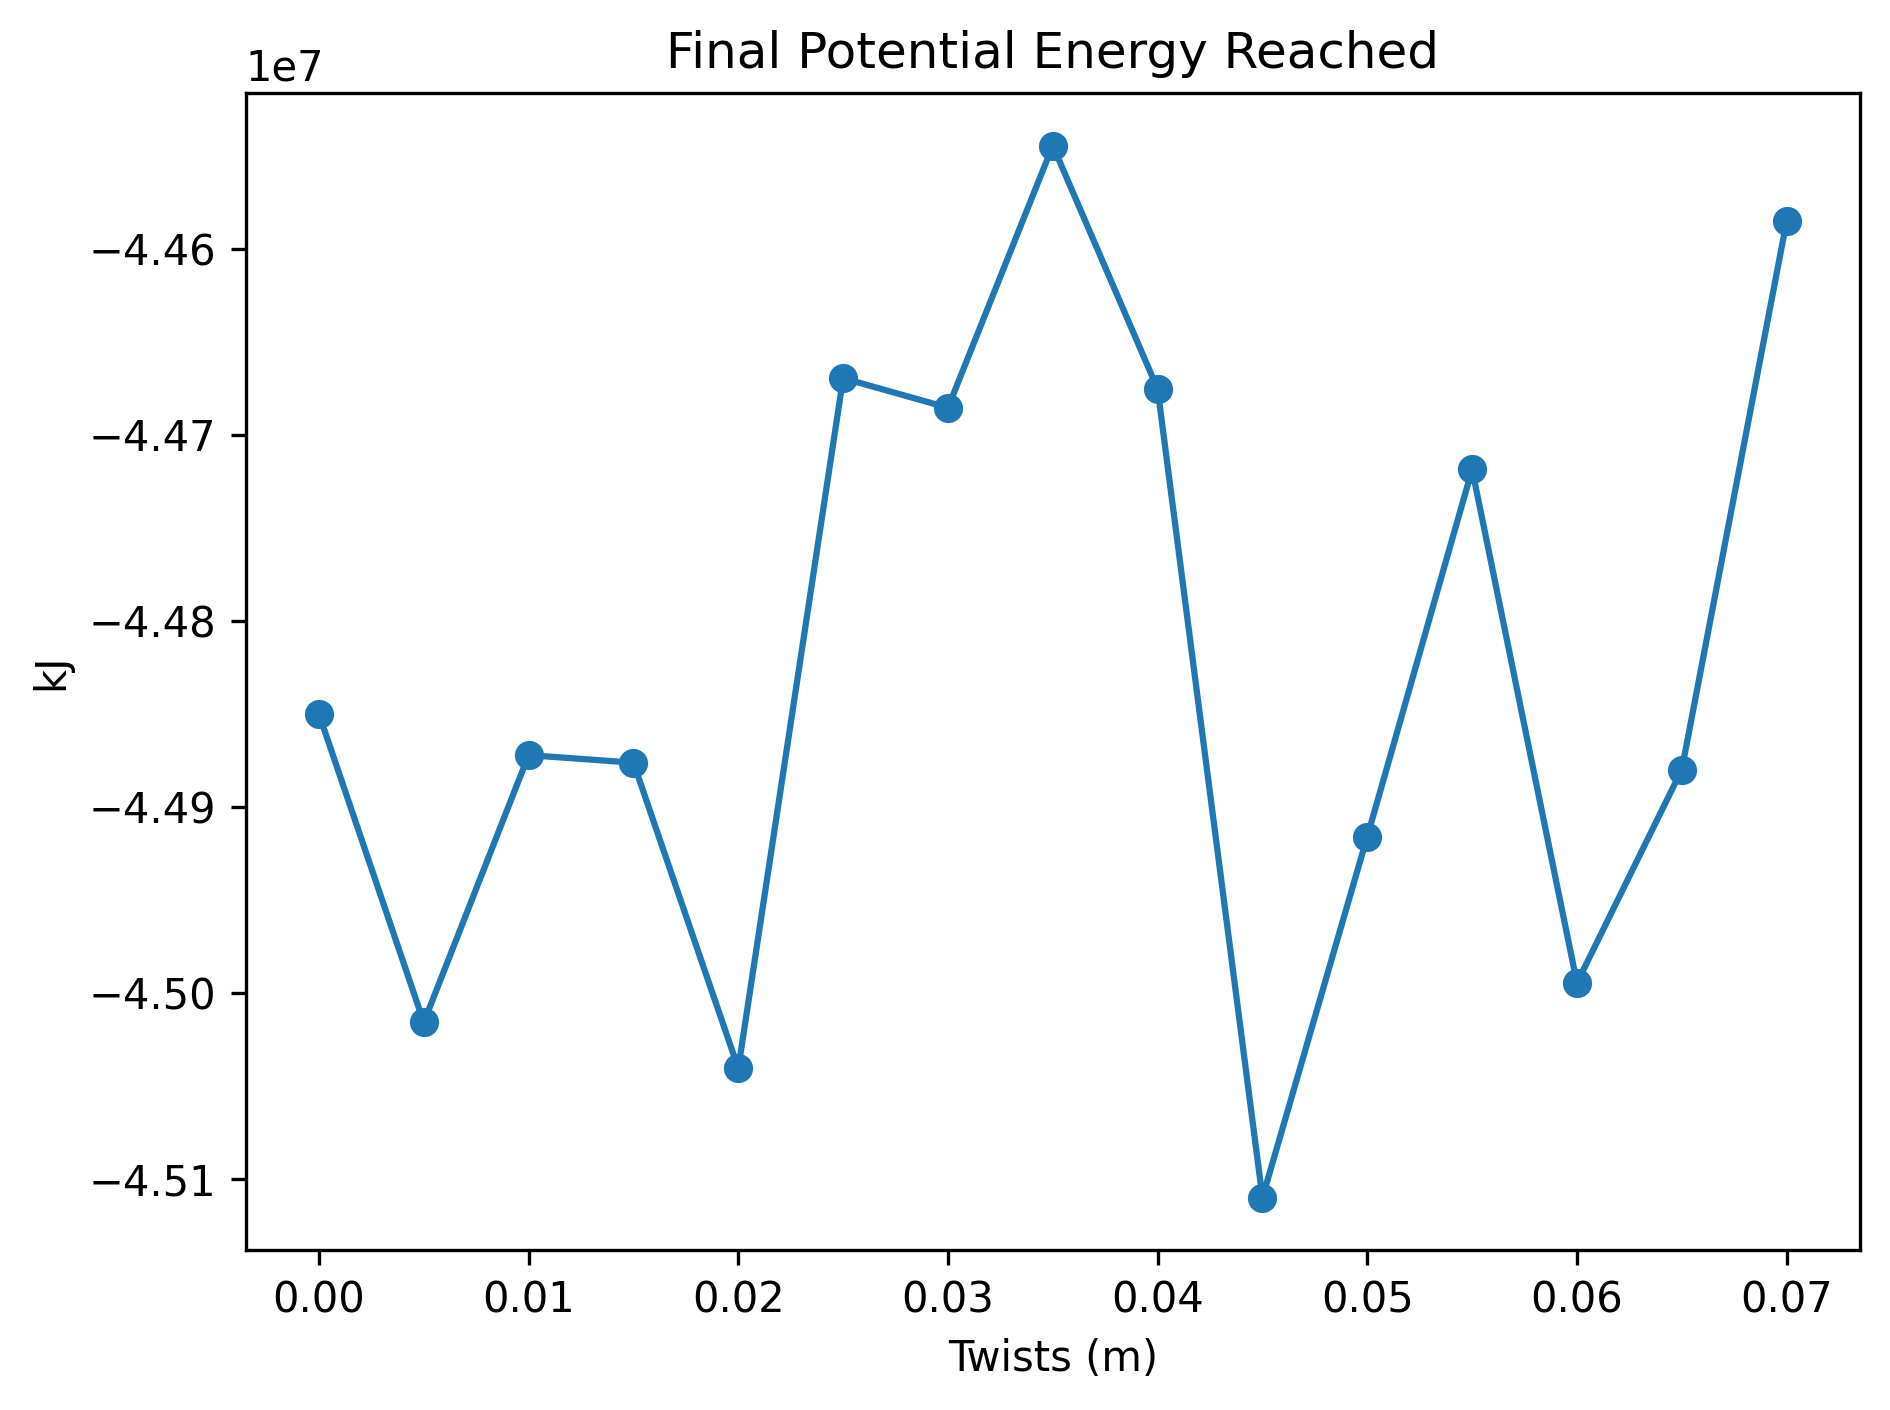

In [28]:
fin_enes = [pots[i][-1] for i in range(n_tws)]

plt.figure(dpi=300)

plt.scatter(twists, fin_enes)
plt.plot(twists, fin_enes)

plt.xlabel("Twists (m)")
plt.ylabel("kJ")
plt.title("Final Potential Energy Reached")

plt.tight_layout()
plt.show()

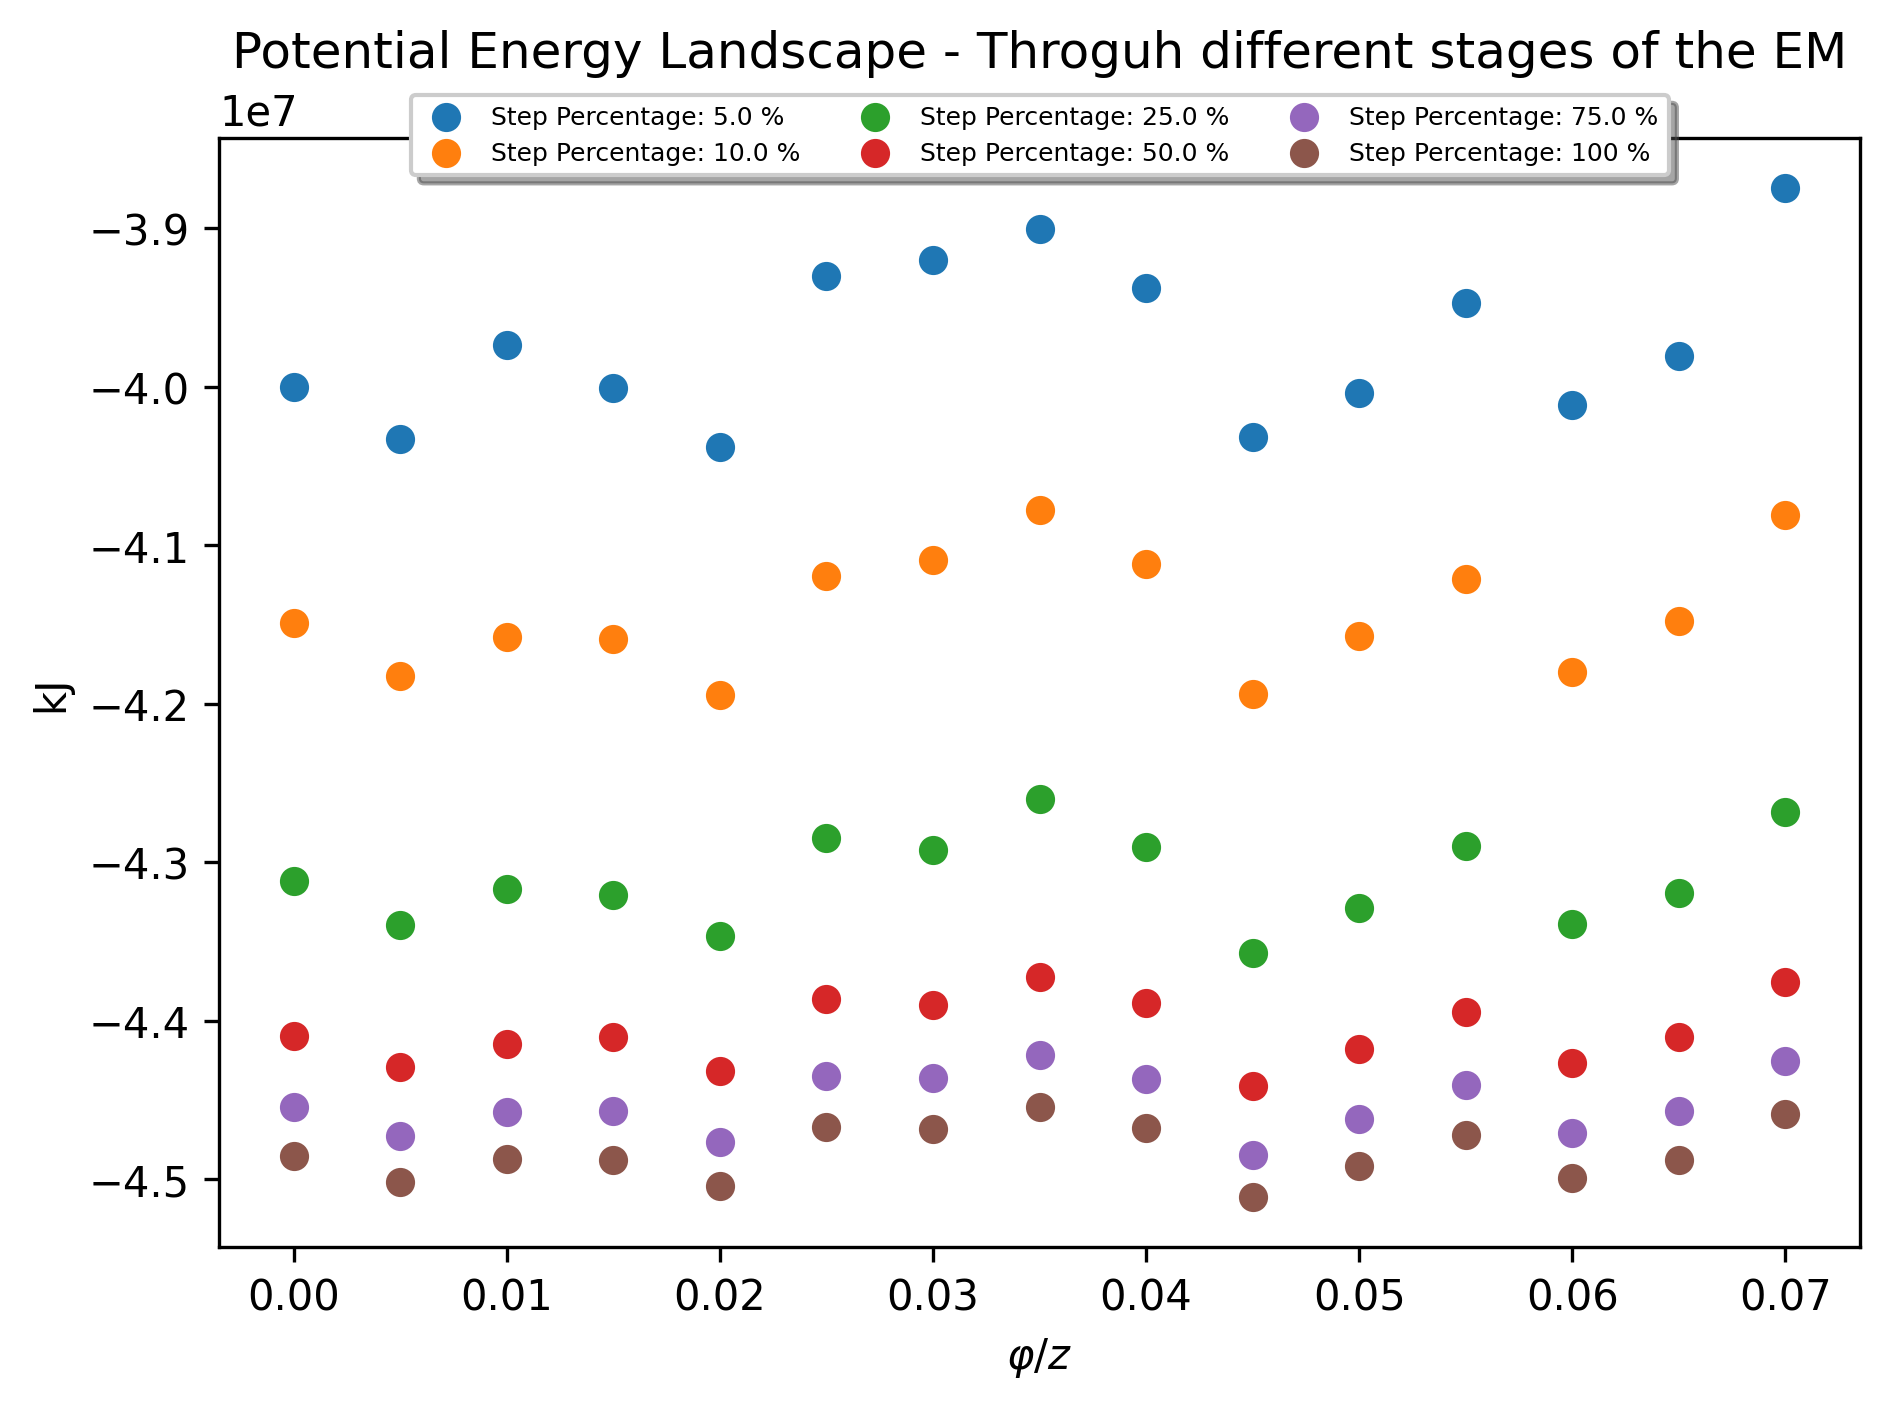

In [32]:
perc = [0.05, 0.1, 0.25, 0.5, 0.75, 1]
plt.figure(dpi=300)

for percentage in perc:
    if percentage == 0:
        energies = [pots[i][0] for i in range(n_tws)]
    else:
        energies = [pots[i][int(percentage * len(steps[i])) - 1] for i in range(n_tws)]
    plt.scatter(twists, energies, label = f'Step Percentage: {percentage*100} %')

plt.xlabel(r'$\varphi/z$')
plt.ylabel('kJ')
plt.title('Potential Energy Landscape - Throguh different stages of the EM')

plt.legend(fontsize=6, loc='upper center', bbox_to_anchor=(0.5, 1.05),
          ncol=3, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()